# Plot and compare atmospheric forcing

Started 2023-04-21

by Eva Lieungh, adapted from [LSP notebook](https://github.com/NorESMhub/noresm-land-sites-platform/tree/main/notebooks/plot_input_data). 

Plots to visualize some of the model inputs for atmospheric forcing, i.e., the dataset providing climatic observations driving model processes such as photosynthesis or evaporation.

Print the current working directory to know where to define paths from:

In [2]:
%%bash
pwd

/mnt/c/Users/evaler/OneDrive - Universitetet i Oslo/Eva/PHD/3_FATES_INCLINE/FATES_INCLINE/src/analysis_and_plotting


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr
import time
import glob

Read in data

In [4]:
# set path for all input data folders
#inputdata_path = f"../../data/inputdata"
inputdata_path = f"../../../../../../../model_output/inputdata/inputdata/"

# Add full inputdata folder names
file_path_cold = f"{inputdata_path}skj_pt_gswp3-cold"
file_path_otc_c = f"{inputdata_path}skj_pt_gswp3-otc"
file_path_warm = f"{inputdata_path}skj_pt_gswp3"
file_path_otc_w = f"{inputdata_path}skj_pt_gswp3-warm-otc"

file_paths = {
    'cold': file_path_cold,
    'otc_c': file_path_otc_c,
    'warm': file_path_warm,
    'otc_w': file_path_otc_w
}

# print one to see if it looks correct
file_path_cold

'../../../../../../../model_output/inputdata/inputdata/skj_pt_gswp3-cold'

Open and combine all the monthly atmospheric NetCDF files into an xarray dataset. Read only temperature. Solar radiation and precipitation should be identical between the data sets.

In [5]:
data = {}

# take the time of this process, could take some minutes
start_time = time.time()

for dataset, path in file_paths.items():
    data_paths = glob.glob(f"{path}/datmdata/*TPQWL*.nc")
    data[dataset] = xr.open_mfdataset(data_paths, 
                                      combine='by_coords', 
                                      decode_times=True)

print(f"--- Time it took to read the data: {round(float(time.time() - start_time), 3)} seconds ---")

--- Time it took to read the data: 319.325 seconds ---


In [7]:
# Create case folder for output plots if necessary
out_dir_path =  Path("../../results/figures/forcing_data")

if not out_dir_path.is_dir():
    out_dir_path.mkdir(parents=True, exist_ok=True)

In [8]:
# Set general plotting options
DPI = 300
TICK_LABEL_FONT_SIZE = 12
AX_LABEL_FONT_SIZE = 14
TITLE_FONT_SIZE = 16

## Full dataset period

In [9]:
# Print dataset info
data

{'cold': <xarray.Dataset>
 Dimensions:  (time: 332880, lat: 1, lon: 1, scalar: 1)
 Coordinates:
   * time     (time) object 1901-01-01 01:30:00 ... 2014-12-31 22:30:00
   * lon      (lon) float32 6.25
   * lat      (lat) float32 60.75
 Dimensions without coordinates: scalar
 Data variables:
     TBOT     (time, lat, lon) float64 dask.array<chunksize=(248, 1, 1), meta=np.ndarray>
     LONGXY   (time, lat, lon) float32 dask.array<chunksize=(248, 1, 1), meta=np.ndarray>
     LATIXY   (time, lat, lon) float32 dask.array<chunksize=(248, 1, 1), meta=np.ndarray>
     EDGEE    (time, scalar, lat, lon) float32 dask.array<chunksize=(248, 1, 1, 1), meta=np.ndarray>
     EDGEW    (time, scalar, lat, lon) float32 dask.array<chunksize=(248, 1, 1, 1), meta=np.ndarray>
     EDGES    (time, scalar, lat, lon) float32 dask.array<chunksize=(248, 1, 1, 1), meta=np.ndarray>
     EDGEN    (time, scalar, lat, lon) float32 dask.array<chunksize=(248, 1, 1, 1), meta=np.ndarray>
     PSRF     (time, lat, lon) flo

#### Annual temperature comparison

In [10]:
datasets = [
    'cold',
    'otc_c',
    'warm',
    'otc_w',
]

In [11]:
temp_annual_mean = {}

for dat in datasets:
    temp_annual_mean[dat] = data[dat]["TBOT"].resample(time='1Y').mean() - 273.15

In [13]:
temp_annual_mean["cold"]["time"][0:10]

<xarray.DataArray 'time' (time: 10)>
array([cftime.DatetimeNoLeap(1901, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1902, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1903, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1904, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1905, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1906, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1907, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1908, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1910, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 1901-12-31 00:00:00 ... 1910-12-31 00:00:00

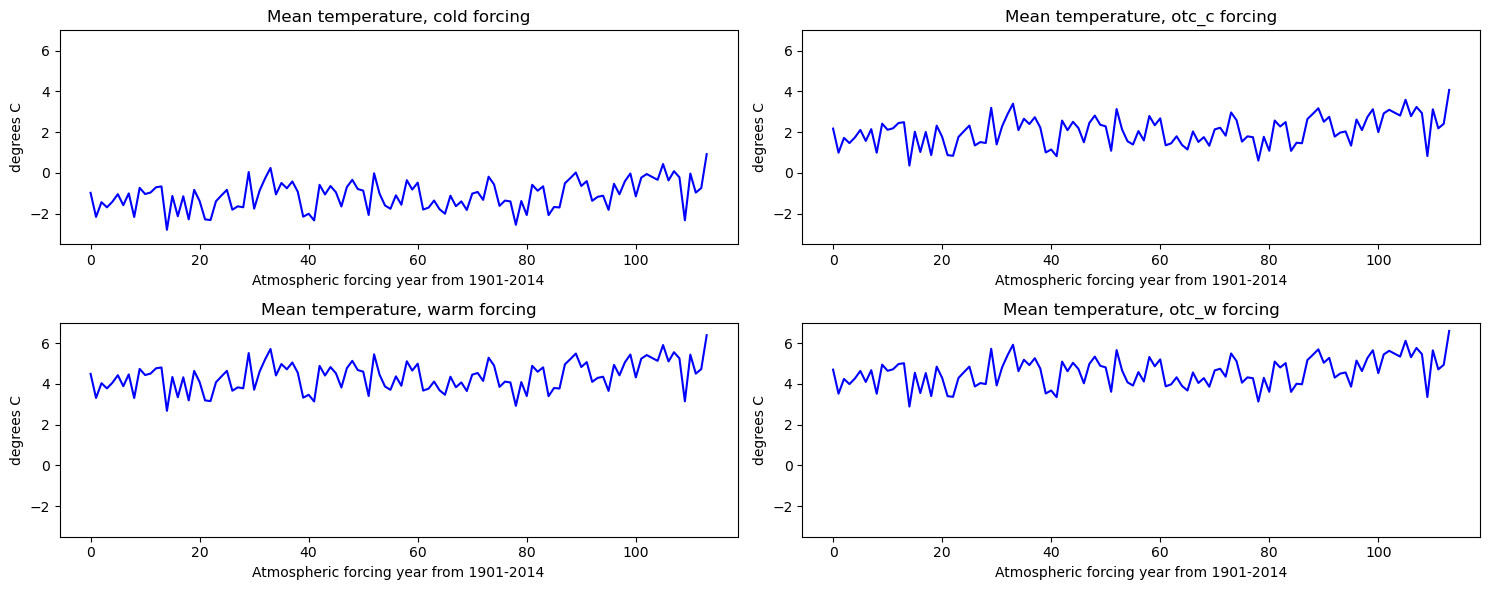

In [24]:
# Instantiate plot
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 6)
)

# Plot in loop
for i, dat in enumerate(datasets):
    ax = axes.flatten()[i]
    # subset variable from data
    temp = temp_annual_mean[dat].isel(lat=0, lon=0)
    ax.plot(range(len(temp["time"])), 
            temp.values,
            color="blue") 
    ax.set_title(f"Mean temperature, {dat} forcing")
    ax.set_xlabel("Atmospheric forcing year from 1901-2014")
    ax.set_ylabel(f"degrees C")
    # set y axis limits
    ax.set_ylim([-3.5, 7])

plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Show the plot

# Save figure
fig.tight_layout()
fig.savefig(fname=f"{out_dir_path}/atmosphere_yearly_temp.png", format='png')

## temperature forcing in single line plot


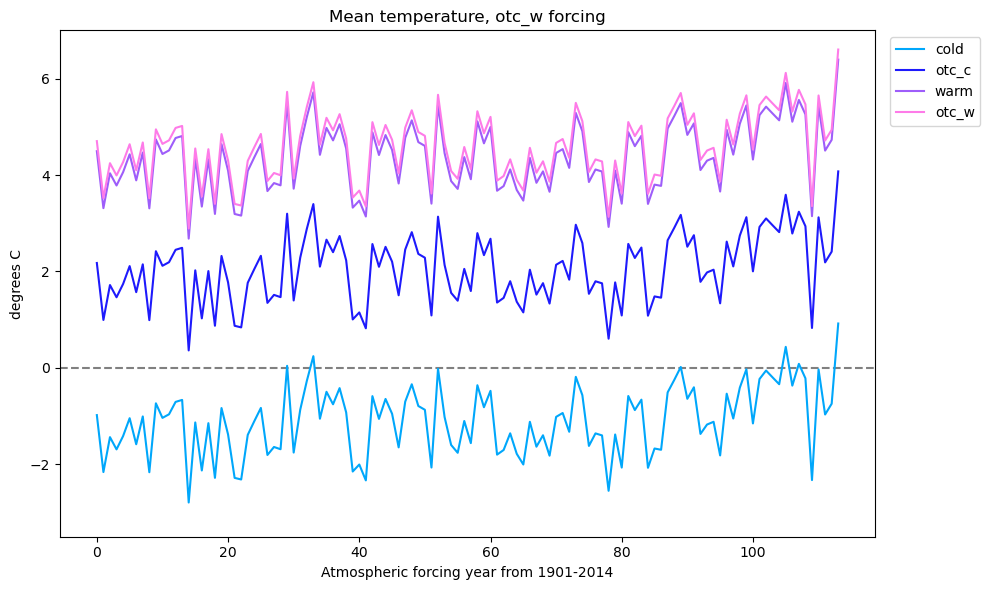

In [33]:
datasets = [
    'cold',
    'otc_c',
    'warm',
    'otc_w',
]

color_gradient = [
    "#00A7FB",
    "#1E1AFC",
    "#9E5DFA",
    "#FE7BE8"
]

# Instantiate figure
fig, ax = plt.subplots(
    figsize=(10, 6)
    )

# Plot in loop
for i, dat in enumerate(datasets):
    temp = temp_annual_mean[dat].isel(lat=0, lon=0)#.squeeze()
    ax.plot(
        range(len(temp["time"])),
        temp.values,
        label=dat,
        color=color_gradient[i]
    )

ax.set_title(f"Mean temperature, {dat} forcing")
ax.set_xlabel("Atmospheric forcing year from 1901-2014")
ax.set_ylabel(f"degrees C")
ax.set_ylim([-3.5, 7])

# add line at 0
ax.axhline(y=0, color='grey', linestyle='dashed', zorder=-1)

# add single legend for all plots
ax.legend(loc='upper left',
          bbox_to_anchor=(1.01, 1))

plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Show the plot

---
## All variables, 1-year period

Temperature, precipitation, total radiation, longwave radiation, humidity, wind, atm. pressure.

Specify custom start and end dates for plotting a short time period with the original temporal resolution, i.e. in 3 hourly timesteps. It should generally be a year or less to maintain readability. Must be within the time range of the data, 1901-01-01 to 2013-12-31 for GSWP3.

In [34]:
subset_time_start = '2013-01-01'  # Format: YYYY-MM-DD
subset_time_end = '2013-12-31'  # Format: YYYY-MM-DD

In [37]:
atm_forcing_subset = {}

# subset the last year
for dat in datasets:
    atm_forcing_subset[dat] = data[dat].isel(time=slice(-12, None))

#atm_forcing_subset = data.sel(
#    time=slice(subset_time_start, subset_time_end)
#)
atm_forcing_subset

{'cold': <xarray.Dataset>
 Dimensions:  (time: 12, lat: 1, lon: 1, scalar: 1)
 Coordinates:
   * time     (time) object 2014-12-30 13:30:00 ... 2014-12-31 22:30:00
   * lon      (lon) float32 6.25
   * lat      (lat) float32 60.75
 Dimensions without coordinates: scalar
 Data variables:
     TBOT     (time, lat, lon) float64 dask.array<chunksize=(12, 1, 1), meta=np.ndarray>
     LONGXY   (time, lat, lon) float32 dask.array<chunksize=(12, 1, 1), meta=np.ndarray>
     LATIXY   (time, lat, lon) float32 dask.array<chunksize=(12, 1, 1), meta=np.ndarray>
     EDGEE    (time, scalar, lat, lon) float32 dask.array<chunksize=(12, 1, 1, 1), meta=np.ndarray>
     EDGEW    (time, scalar, lat, lon) float32 dask.array<chunksize=(12, 1, 1, 1), meta=np.ndarray>
     EDGES    (time, scalar, lat, lon) float32 dask.array<chunksize=(12, 1, 1, 1), meta=np.ndarray>
     EDGEN    (time, scalar, lat, lon) float32 dask.array<chunksize=(12, 1, 1, 1), meta=np.ndarray>
     PSRF     (time, lat, lon) float32 dask.a

Subset temperature and make a multi-line plot for the last forcing year (2014)

In [71]:
subset_TBOT = {}

# TBOT is the only variable to differ between the data. 
for dat in datasets:
    subset_TBOT[dat] = (atm_forcing_subset[dat]["TBOT"] - 273.15).dropna(dim="time")
    #TBOT_list = []
#
    ## Temperature, convert from K to °C
    #temp_subset = (atm_forcing_subset[dat]["TBOT"] - 273.15).dropna(dim="time")
    #TBOT_list.append(temp_subset)
    #
    #subset_TBOT[dat] = TBOT_list

[<xarray.DataArray 'TBOT' (time: 12, lat: 1, lon: 1)>
 dask.array<sub, shape=(12, 1, 1), dtype=float32, chunksize=(12, 1, 1), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) object 2014-12-30 13:30:00 ... 2014-12-31 22:30:00
   * lon      (lon) float32 6.25
   * lat      (lat) float32 60.75]

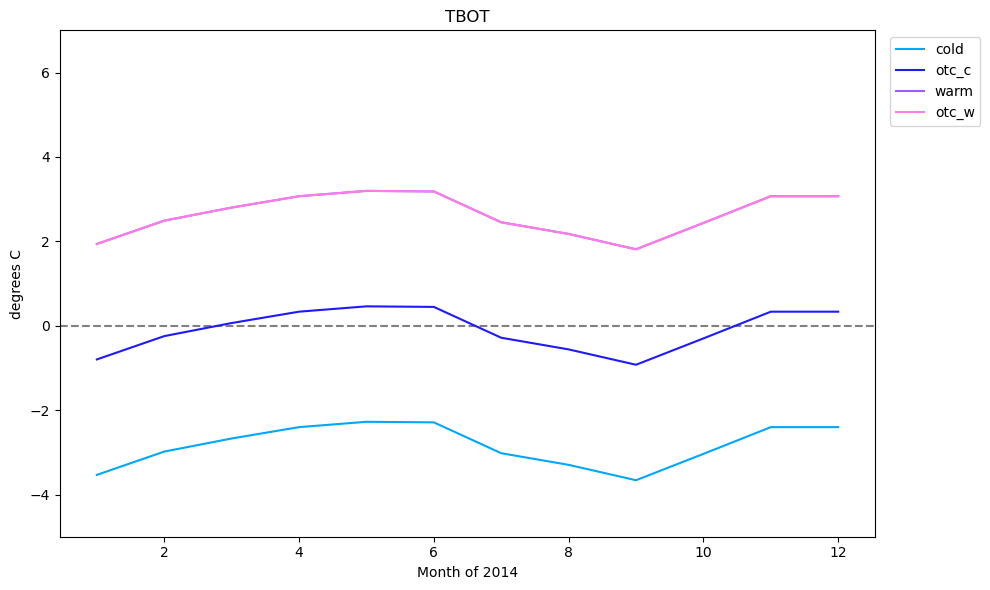

In [74]:
datasets = [
    'cold',
    'otc_c',
    'warm',
    'otc_w',
]

color_gradient = [
    "#00A7FB",
    "#1E1AFC",
    "#9E5DFA",
    "#FE7BE8"
]

# Instantiate figure
fig, ax = plt.subplots(
    figsize=(10, 6)
    )

# Plot in loop
for i, dat in enumerate(datasets):
    temp = subset_TBOT[dat]#.isel(lat=0, lon=0)#.squeeze()
    ax.plot(
        range(1, 13), #range(len(temp["time"]))
        temp.values.flatten(), # variable.values.flatten()
        label=dat,
        color=color_gradient[i]
    )

ax.set_title(f"TBOT")
ax.set_xlabel("Month of 2014")
ax.set_ylabel(f"degrees C")
ax.set_ylim([-5, 7])

# add line at 0
ax.axhline(y=0, color='grey', linestyle='dashed', zorder=-1)

# add single legend for all plots
ax.legend(loc='upper left',
          bbox_to_anchor=(1.01, 1))

plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Show the plot

# Save figure
fig.tight_layout()
fig.savefig(fname=f"{out_dir_path}/atmosphere_temperature_2014.png", format='png')

Subset the other variables and plot those

In [60]:
variable_list = []

# Incident longwave radiation
radation_longwave_subset = atm_forcing_subset["warm"]["FLDS"].dropna(dim="time")
variable_list.append(radation_longwave_subset)
# Specific humidity
humidity_subset = atm_forcing_subset["warm"]["QBOT"].dropna(dim="time")
variable_list.append(humidity_subset)
# Wind speed
wind_subset = atm_forcing_subset["warm"]["WIND"].dropna(dim="time")
variable_list.append(wind_subset)
# Atm. pressure, convert to hPa
pressure_subset = (atm_forcing_subset["warm"]["PSRF"] * 0.01).dropna(dim="time")
variable_list.append(pressure_subset)


In [61]:
# Label dictionary
subset_plot_dict = {
    "TBOT": {
        "y_axis": "2m air temperature",
        "unit": "[°C]",
        "color": "#C0392B",
    },
    "FLDS": {
        "y_axis": "Incident longwave radiation",
        "unit": "[W/m²]",
        "color": "#FEF854",
    },
    "QBOT": {
        "y_axis": "2m specific humidity",
        "unit": "[kg/kg]",
        "color": "#8EA9F6",
    },
    "WIND": {
        "y_axis": "2m wind speed",
        "unit": "[m/s]",
        "color": "#F00BF3",
    },
    "PSRF": {
        "y_axis": "Surface pressure",
        "unit": "[hPa]",
        "color": "#4B4B4B",
    },
}

In [63]:
for variable in variable_list:
    print(variable)

<xarray.DataArray 'FLDS' (time: 12, lat: 1, lon: 1)>
dask.array<getitem, shape=(12, 1, 1), dtype=float32, chunksize=(12, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 2014-12-30 13:30:00 ... 2014-12-31 22:30:00
  * lon      (lon) float32 6.25
  * lat      (lat) float32 60.75
Attributes:
    long_name:  incident longwave radiation
    units:      W/m**2
    mode:       time-dependent
<xarray.DataArray 'QBOT' (time: 12, lat: 1, lon: 1)>
dask.array<getitem, shape=(12, 1, 1), dtype=float32, chunksize=(12, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 2014-12-30 13:30:00 ... 2014-12-31 22:30:00
  * lon      (lon) float32 6.25
  * lat      (lat) float32 60.75
Attributes:
    long_name:  specific humidity at the lowest atm level
    units:      kg/kg
    mode:       time-dependent
<xarray.DataArray 'WIND' (time: 12, lat: 1, lon: 1)>
dask.array<getitem, shape=(12, 1, 1), dtype=float32, chunksize=(12, 1, 1), chunktype=numpy.ndarray>
Coordinate

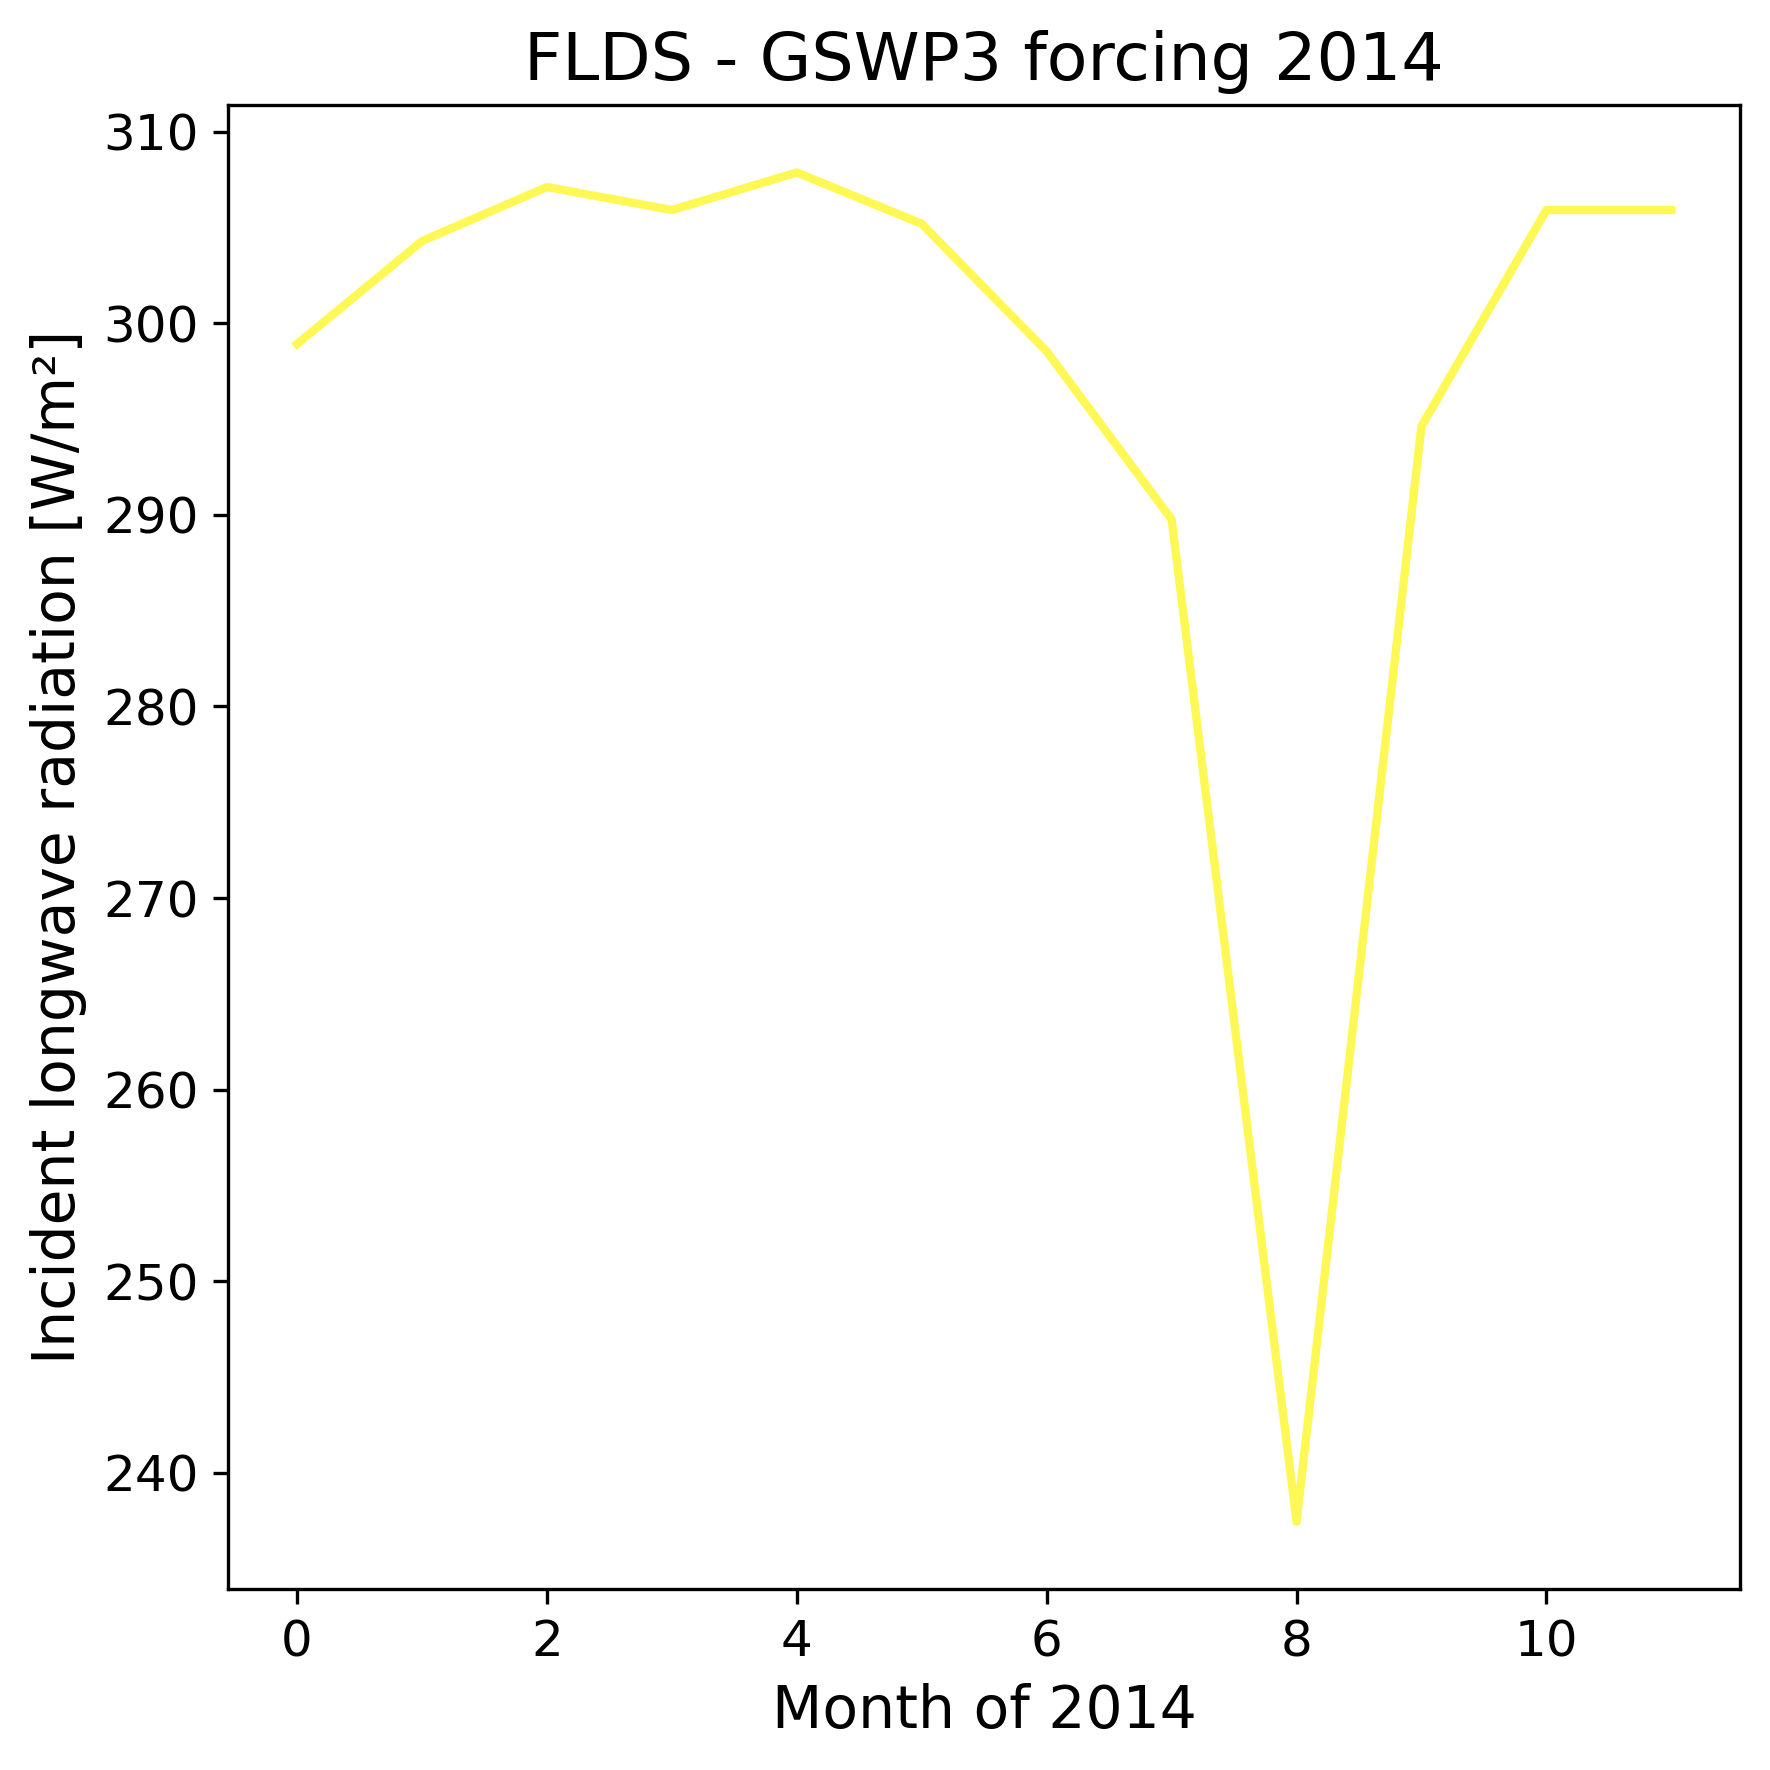

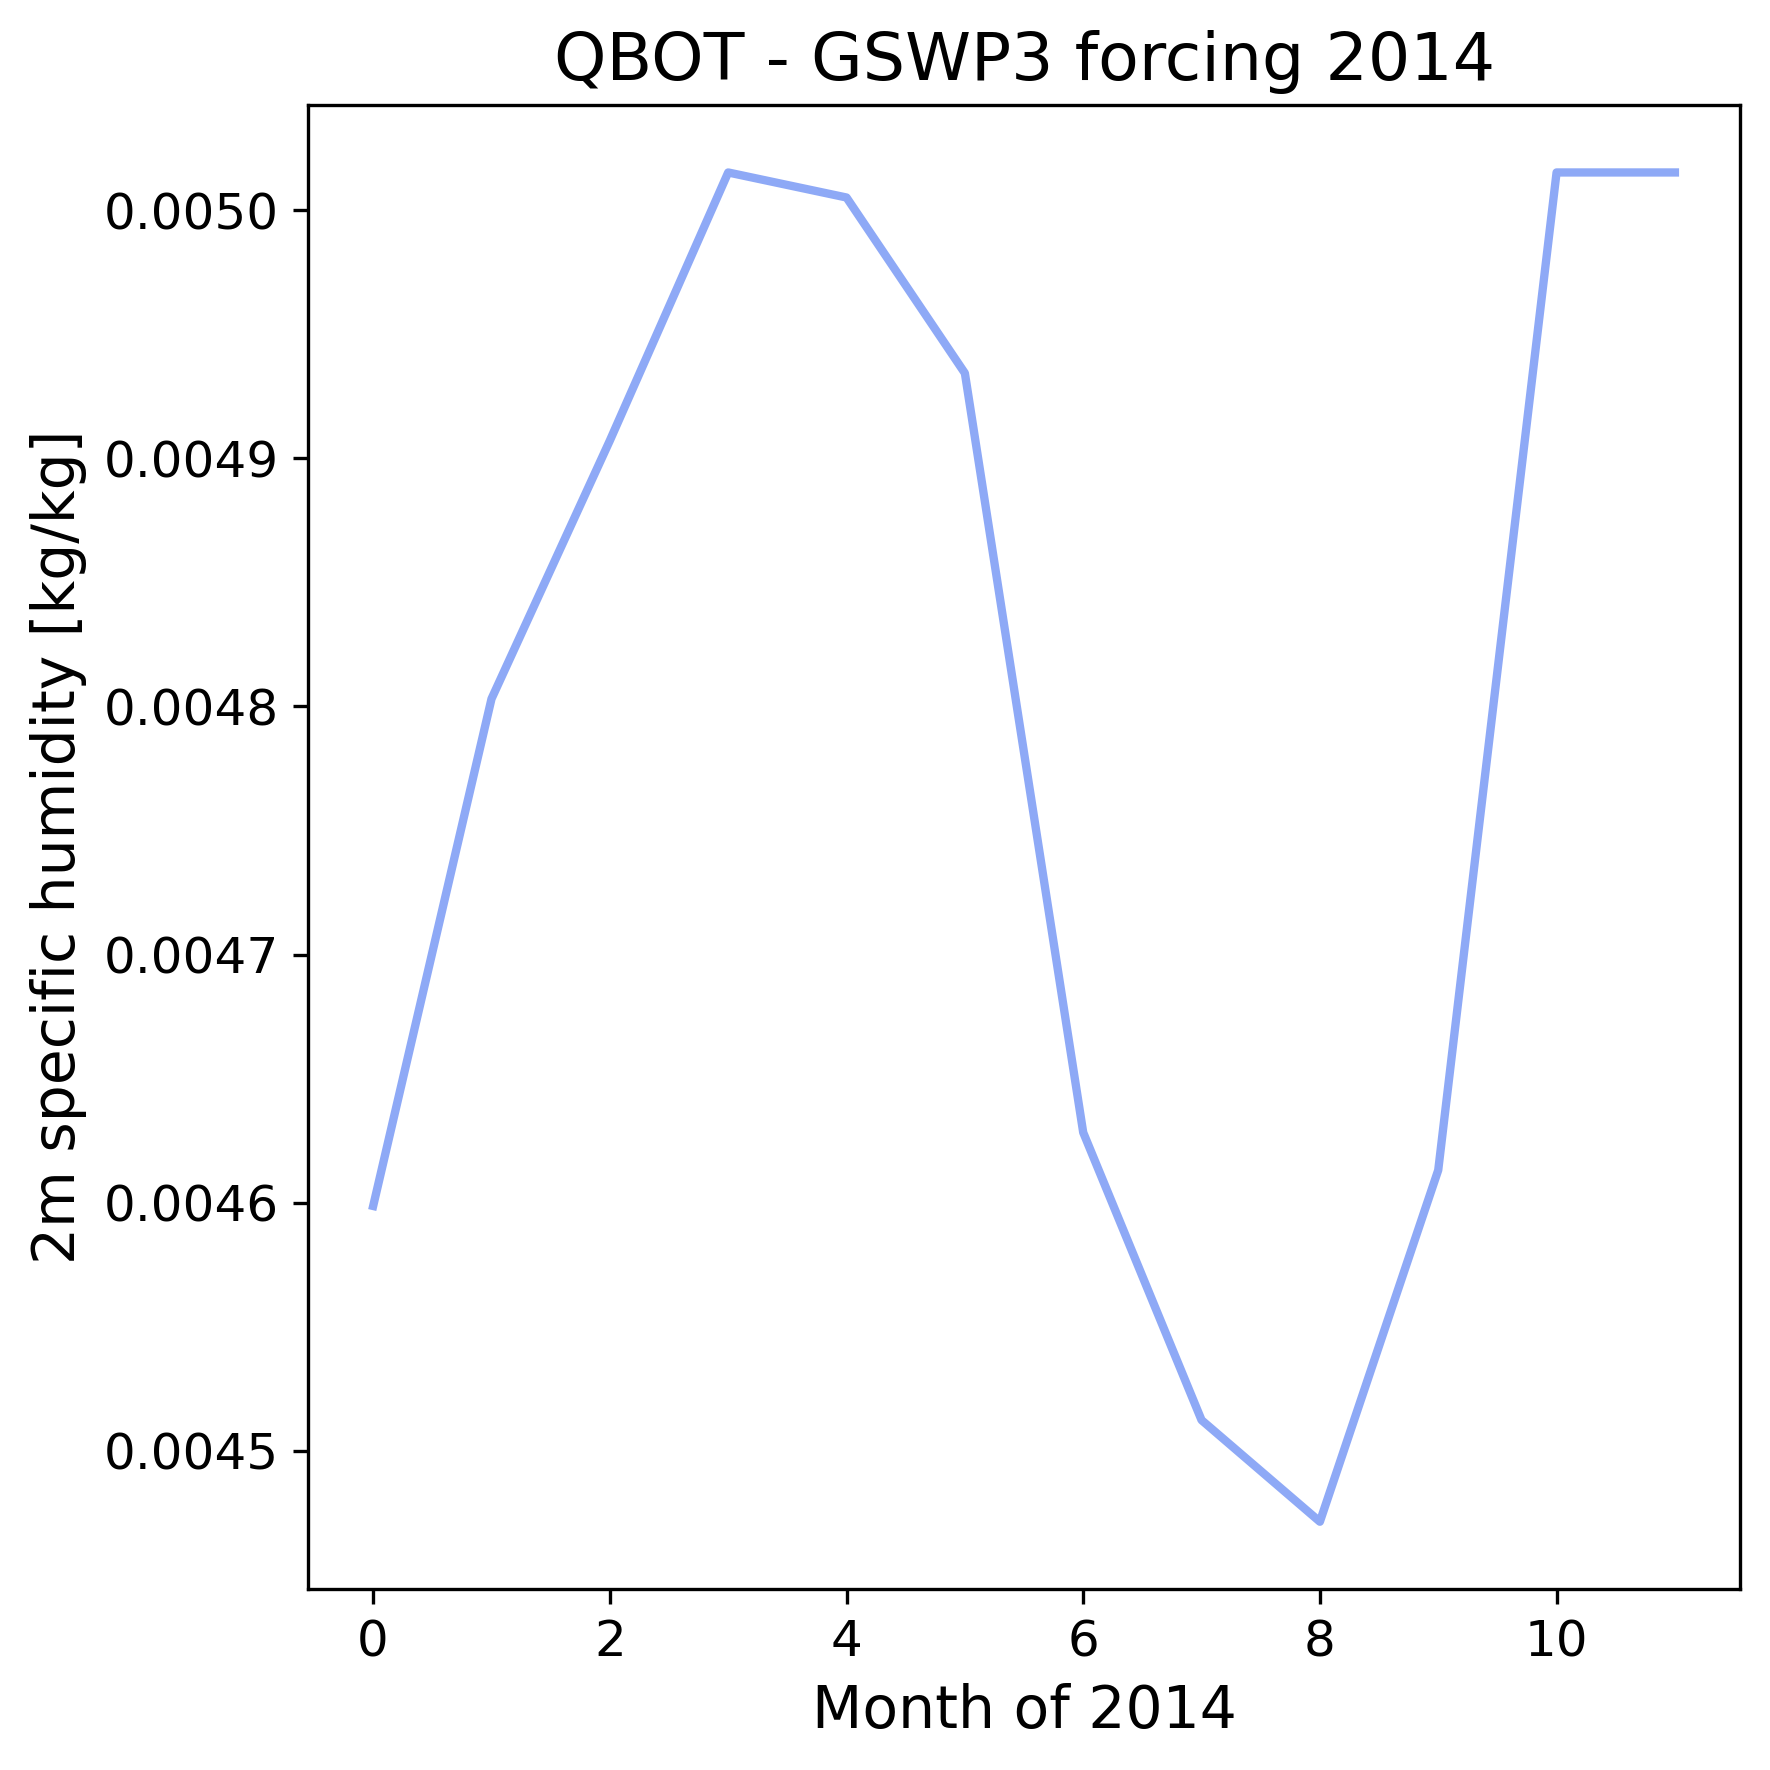

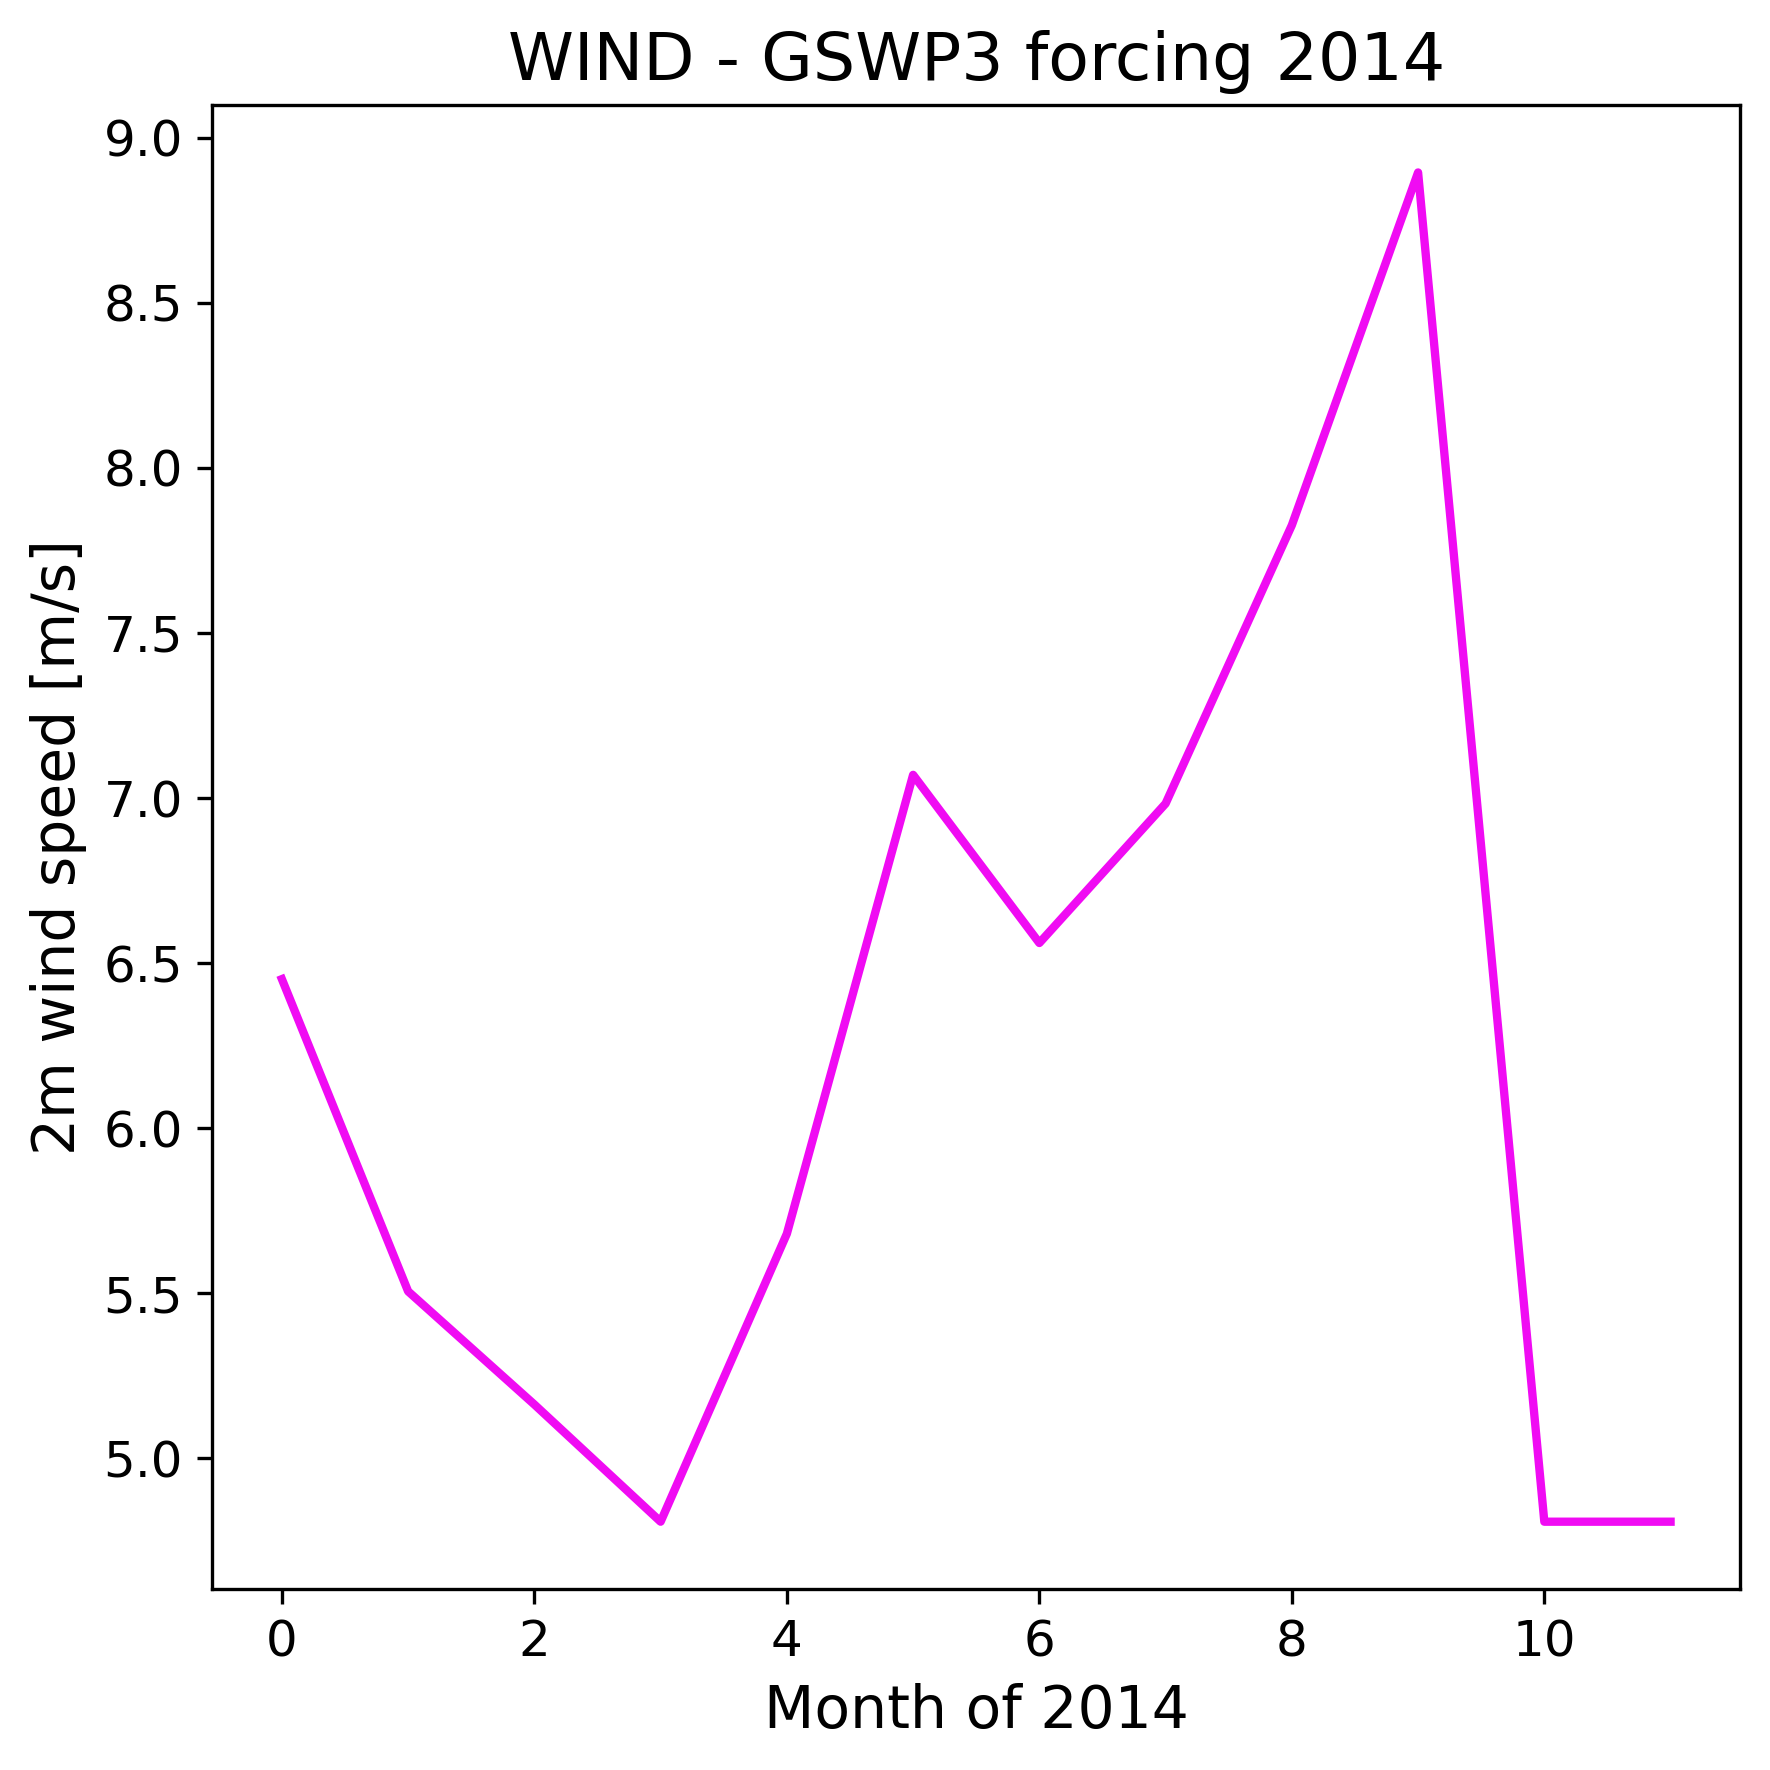

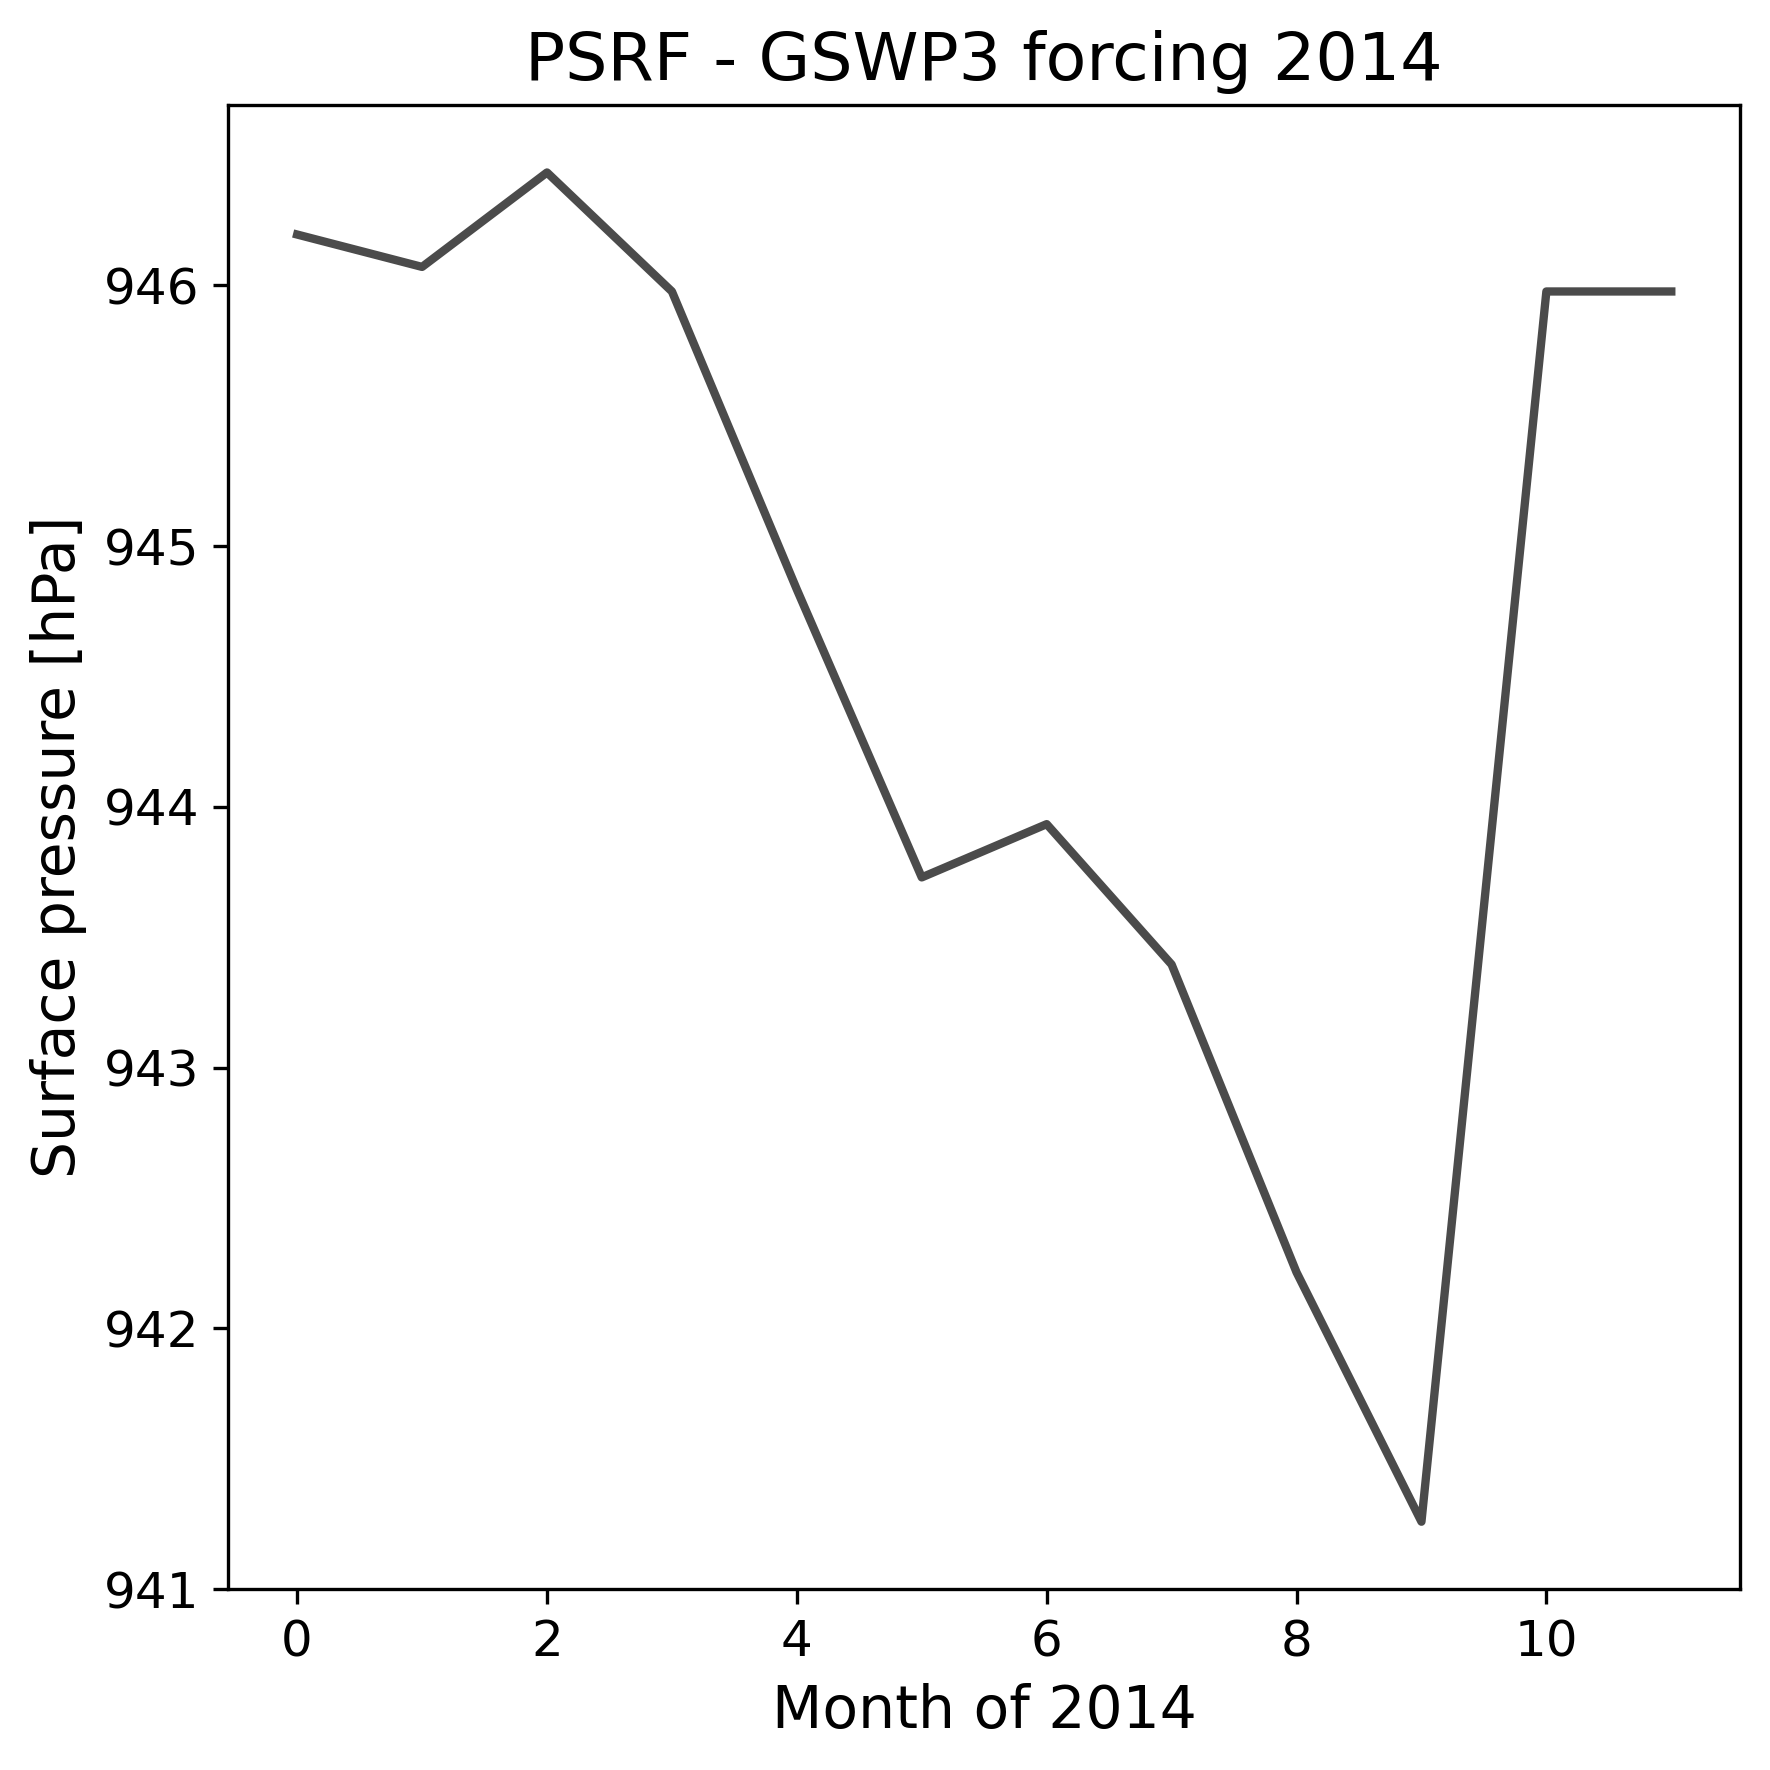

In [69]:
# Create plots for each variable
for variable in variable_list:
    
    # Get plot settings for current variable
    current_var_dict = subset_plot_dict.get(variable.name)
    
    # Instantiate plot
    fig, ax = plt.subplots(figsize=(6, 6), dpi=DPI)

    ax.plot(range(12),
            variable.values.flatten(),
            color=current_var_dict.get('color'),
            linewidth=2,
           )
    
    # Other plot layout settings
    ax.set_title(f"{variable.name} - GSWP3 forcing 2014", size=TITLE_FONT_SIZE)

    ax.set_ylabel(current_var_dict.get('y_axis') + " " + current_var_dict.get('unit'),
                  fontsize=AX_LABEL_FONT_SIZE)
    ax.set_xlabel("Month of 2014", fontsize=AX_LABEL_FONT_SIZE)

    ax.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONT_SIZE)

    # Save figure
    fig.tight_layout()
    fig.savefig(fname=f"{out_dir_path}/atmosphere_{variable.name}_2014.png", format='png')

ValueError: too many values to unpack (expected 2)

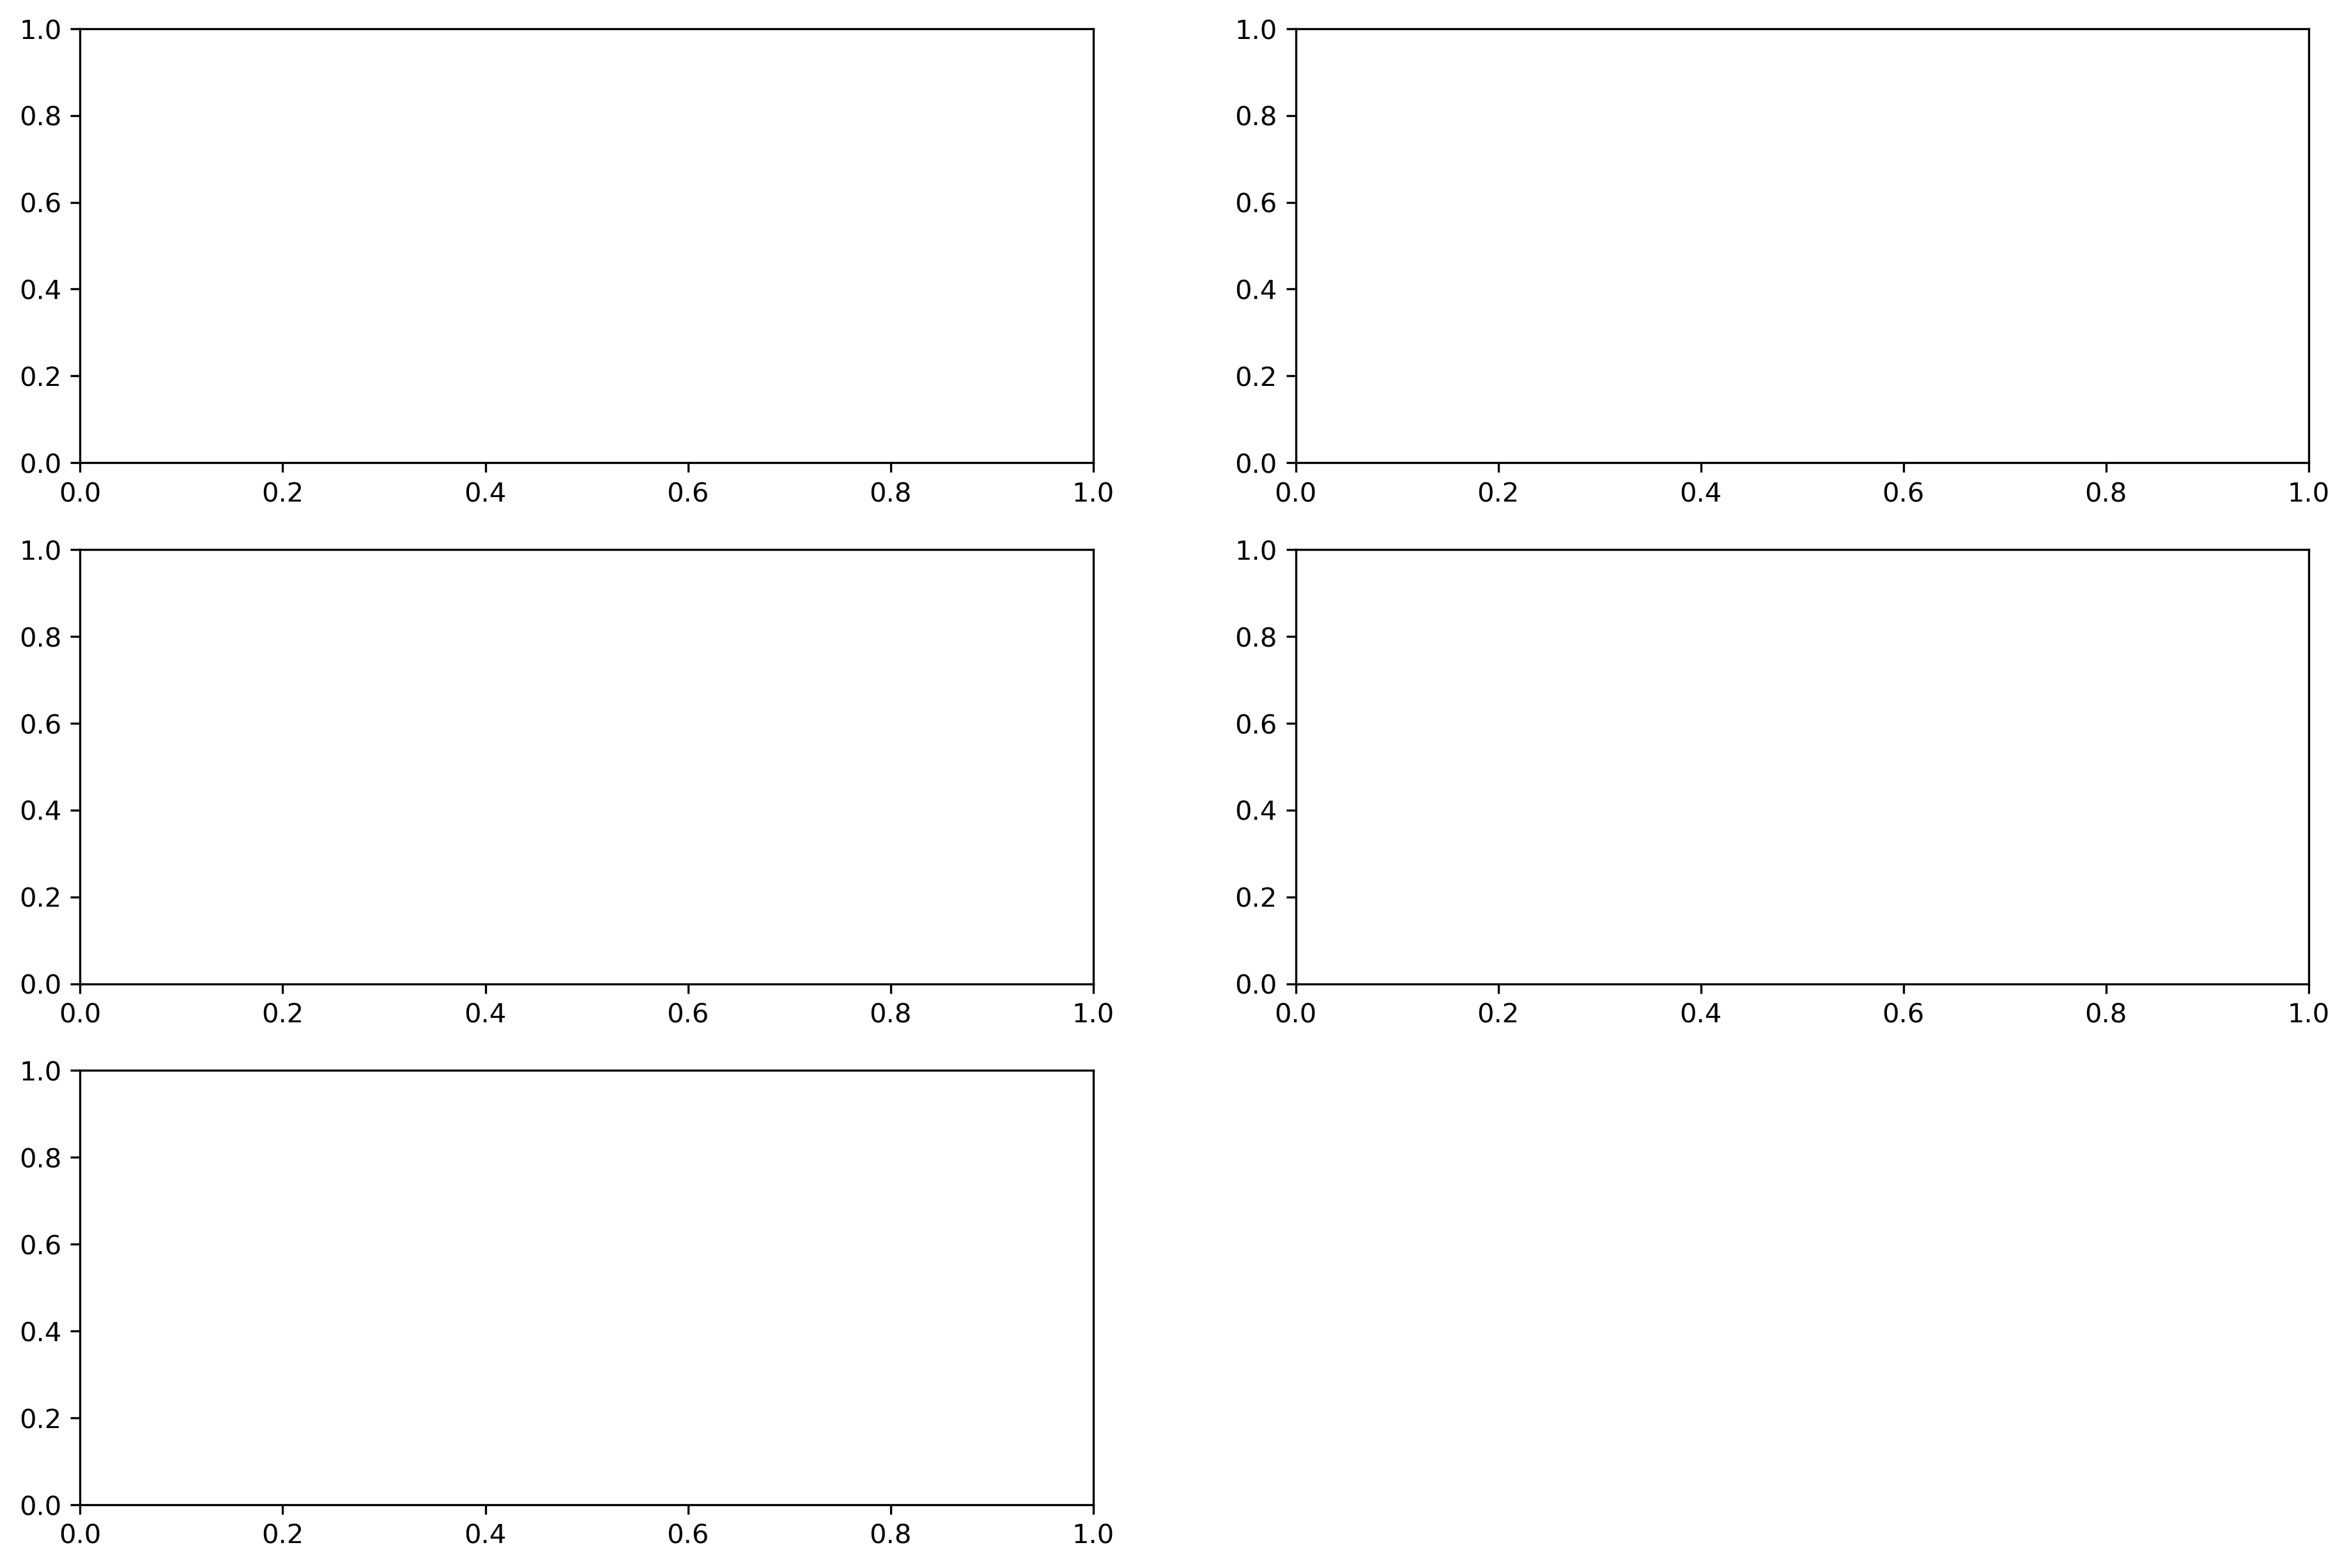

In [ ]:
datasets = [
    'cold',
    'otc_c',
    'warm',
    'otc_w',
]

# Instantiate figure with individual figures next to each other
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(15, 10), 
    dpi=DPI
)

# Delete empty axis object since number of variables is odd
if len(axes.flatten()) != len(variable_list):
    if len(axes.flatten()) == 2:
        fig.delaxes(axes[-1])
    else:
        fig.delaxes(axes[-1, -1])


# Create plots for each variable
for i, variable in variable_list:
    data = subset_lists[variable]
    # Get plot settings for current variable
    current_var_dict = subset_plot_dict.get(variable.name)
    
    # get the current axis object
    ax = axes.flatten()[i]  # Get the appropriate axis object
    
    ax.plot(variable.time,
            variable.values.flatten(),
            label=dat,
            color=color_gradient[j],
            linewidth=2,
           )
    
    # Other plot layout settings
    ax.set_title(f"{variable.name} - GSWP3 forcing 2014", size=TITLE_FONT_SIZE)

    ax.set_ylabel(current_var_dict.get('y_axis') + " " + current_var_dict.get('unit'),
                  fontsize=AX_LABEL_FONT_SIZE)
    ax.set_xlabel("Date", fontsize=AX_LABEL_FONT_SIZE)

    ax.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONT_SIZE)

# add single legend for all plots
ax.legend(loc='upper left',
          bbox_to_anchor=(1.05, 1))

plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Show the plot

# Save figure
fig.tight_layout()
fig.savefig(fname=f"{out_dir_path}/atmosphere_{variable.name}_2014.png", format='png')